In [5]:
import os
import numpy as np
import pandas as pd
from scipy.signal import correlate
import matplotlib.pyplot as plt

from utils.plot_utils import setup_matplotlib

In [6]:
# Plot settings
setup_matplotlib()

In [10]:
df = pd.read_parquet('../data/real/processed/train/multisine_20251017_run1.parquet')

<Axes: >

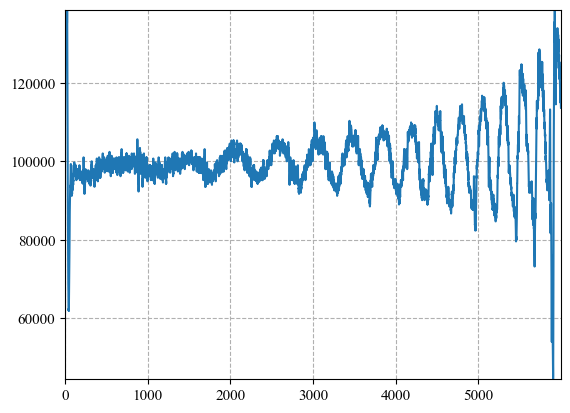

In [12]:
df['m1_erpm'].plot()

In [8]:
file_name = f'square_20251017'
df_sim = pd.read_parquet(os.path.join('idsia_mpc/control_engineering_practice/data/sim/new/', f"{file_name}.parquet"))
runs = [1, 2, 3, 4, 5]
df_real_dict = {}

for run in runs:
    try:
        file_name_real = f'{file_name}_run{run}.parquet'
        df_real = pd.read_parquet(os.path.join('data/real/processed/train', file_name_real))
        df_real = df_real.rename(columns={'torch_yaw': 'torque_yaw'})
        df_real[['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']] = df_real[['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']].rolling(10, min_periods=1, center=True).mean()
        # df_real[["torque_roll", "torque_pitch"]] = -df_real[["torque_pitch", "torque_roll"]]

        # Store dynamically
        df_real_dict[f'run{run}'] = df_real
    except Exception as e:
        print(e)
        continue

FileNotFoundError: [Errno 2] No such file or directory: 'idsia_mpc/control_engineering_practice/data/sim/new/square_20251017.parquet'